# **SETUP**

In [22]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

load_dotenv()

if os.environ.get("GROQ_API_KEY"):
    print("Bro API KEY Variable exists")
else:
    raise ValueError("GROQ_API_KEY not found")

Bro API KEY Variable exists


# **Tools**

In [23]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun(
    description="This is a tool to search the web for news"
)

In [24]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia_tool = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(),
    description="This is a tool to search Wikipedia"
)

In [25]:
from langchain.tools import tool

@tool
def enterprise_tool(query: str) -> str:
    """This is a tool to send emails to employees"""

    return "Email Sent"

# **TOOLKIT**

In [26]:
ToolKit = [search_tool, wikipedia_tool, enterprise_tool]

# **ReAct Agent**

In [27]:
from langchain.agents import create_agent

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.1,
    max_tokens=1000,
)

In [28]:
agent = create_agent(model, tools=ToolKit)

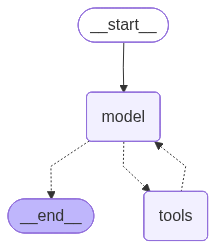

In [29]:
agent

In [30]:
example_query = "Give me the latest news about the stock market"

In [19]:
events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Give me the latest news about the stock market
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (4q2btrq3z)
 Call ID: 4q2btrq3z
  Args:
    query: latest stock market news
================================= Tool Message =================================
Name: duckduckgo_search

Stock market ... Stock Market News ... Dell stock soars after Nvidia contract with TotalEnergies Bonds Digital Real Estate Realty News Technicals Technical Chart Visualize Screener Mind Over Money Web Stories Markets Data The Golden Thumb Rule ... The latest stock market news USA indicates that while rate hikes have been effective in controlling inflation, they have also led to increased market ... Latest Stock News, Stock Market At present, Inventory Market Headlines ... The most recent news flashes level to the general market situation of the ... By staying informed o

KeyboardInterrupt: 

# **WITHOUT BINDING(WITHOUT TOOLS)**

In [32]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

llm_groq.invoke("What's the latest news about the stock market?")

AIMessage(content="I'm not able to provide real-time or the most recent news about the stock market. However, I can suggest some ways for you to stay up-to-date on the latest developments.\n\nYou can check reputable financial news websites such as Bloomberg, CNBC, or The Wall Street Journal for the latest news and updates on the stock market. These websites provide real-time data, analysis, and news on the stock market, as well as expert opinions and commentary.\n\nAdditionally, you can also follow financial news on social media platforms or sign up for newsletters and alerts from financial institutions and news organizations to stay informed about the latest developments in the stock market.\n\nSome popular sources for stock market news include:\n\n* Bloomberg: [www.bloomberg.com](http://www.bloomberg.com)\n* CNBC: [www.cnbc.com](http://www.cnbc.com)\n* The Wall Street Journal: [www.wsj.com](http://www.wsj.com)\n* Yahoo Finance: [finance.yahoo.com](http://finance.yahoo.com)\n* Google 

# **WITH BINDING**

In [33]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

llm_binded = llm_groq.bind_tools(ToolKit)

llm_binded.invoke("What's the latest news about the stock market?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'gtz659kpm', 'function': {'arguments': '{"query":"latest stock market news"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 361, 'total_tokens': 381, 'completion_time': 0.058286485, 'completion_tokens_details': None, 'prompt_time': 0.019102354, 'prompt_tokens_details': None, 'queue_time': 0.055451585, 'total_time': 0.077388839}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e2b3e-8d04-7c23-8bca-a8a1ab40cfa3-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest stock market news'}, 'id': 'gtz659kpm', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 361, 'output_tokens': 20, 'total_tokens': 381})